In [1]:
from cats.cdataframe   import CDataFrame   # tool for extracting data from root files (made by your local developer, Mason Buchanan)

Welcome to JupyROOT 6.28/10


In [2]:
import matplotlib.pyplot as plt    # Matplotlib is the most common plotting package for Python

#The next line is a 'magic' command (indicated by the '%'). These tend to do useful meta things.
%matplotlib inline
#This one makes plots show up in your notebooks. (Note that you can't put comments after it on the same line!)

import pandas as pd                # Some additional data-handling tools
import numpy as np                 # "Numerical python". You need this to process data efficiently
import glob                        # Might be useful for getting files
import cdms
from rawio.IO import *             # Useful for reading binary files which contain raw pulses
import ROOT

In [3]:
Wgamma1_noisefile = '/project/6049244/share/SimData/DMC_SNOLAB_HV/HV100mm_ER_1keV_50V_positiveBias_releaseV05-03/Processed_1keV_50V_1Wgamma_Templates/Noise/Test_Filter_51241008_000000.root'
Wgamma3_noisefile = '/project/6049244/share/SimData/DMC_SNOLAB_HV/HV100mm_ER_1keV_50V_positiveBias_3Wgamma_releaseV05-03/Processed_1keV_50V_3Wgamma_Templates/Noise/Test_Filter_51241007_000000.root'

Text(0, 0.5, 'Amplitude [Arb.]')

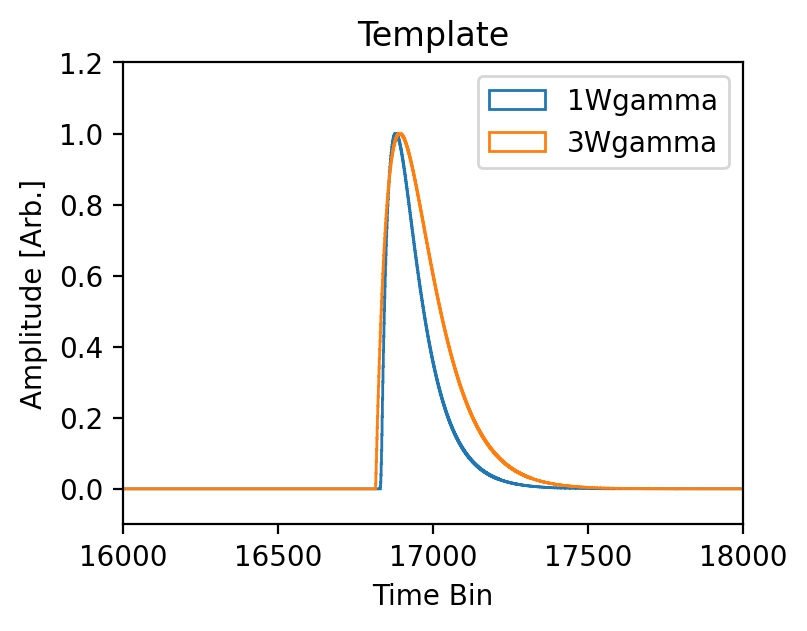

In [8]:
plt.figure(figsize=(4,3), dpi=200)

for sample, name in [(Wgamma1_noisefile, '1Wgamma'), (Wgamma3_noisefile, '3Wgamma')]:

    # Open the ROOT file
    file = ROOT.TFile.Open(sample)
    hist = file.Get(f'zip14/PTTemplateTime')  # Replace 'histname' with the name of your histogram
    # Extract histogram data
    n_bins = hist.GetNbinsX()
    bin_edges = np.array([hist.GetXaxis().GetBinLowEdge(i) for i in range(1, n_bins + 2)])
    bin_contents = np.array([hist.GetBinContent(i) for i in range(1, n_bins + 1)])
    # Close the ROOT file
    file.Close()
    
    plt.hist(bin_edges[:-1], bins=bin_edges, weights=bin_contents, histtype='step', label = name)
    
    
plt.xlim(16000, 18000)
plt.ylim(-0.1, 1.2)
plt.legend()
plt.title('Template')
plt.xlabel('Time Bin')
plt.ylabel('Amplitude [Arb.]')